<a href="https://colab.research.google.com/github/souravk03/Machine-Learning-404/blob/main/Day_60_61_Gradient_Descent_in_Ridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

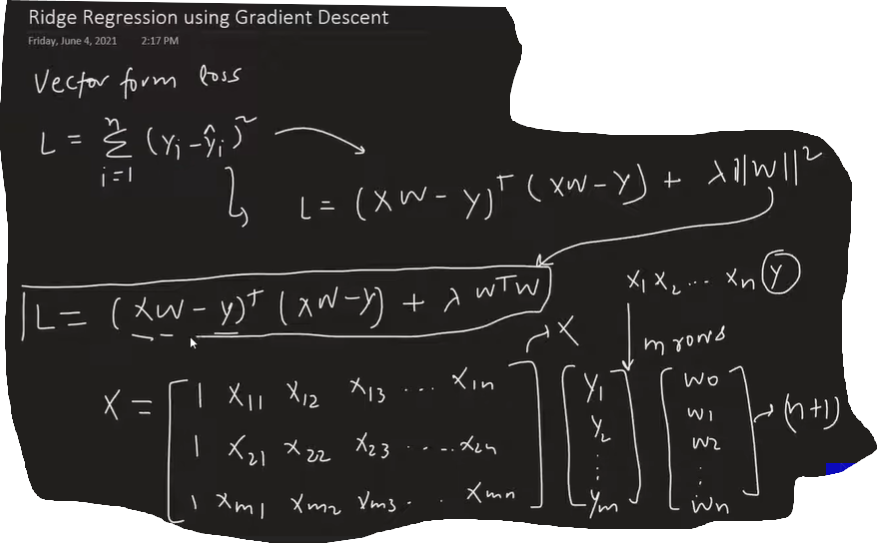

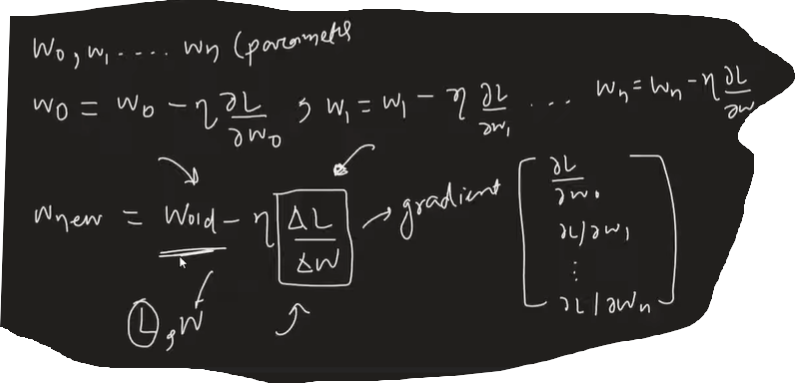

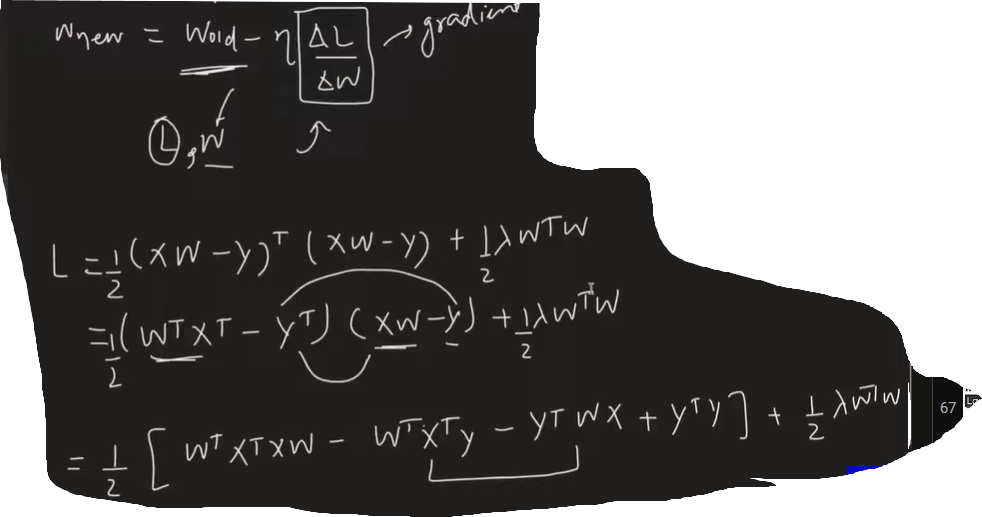

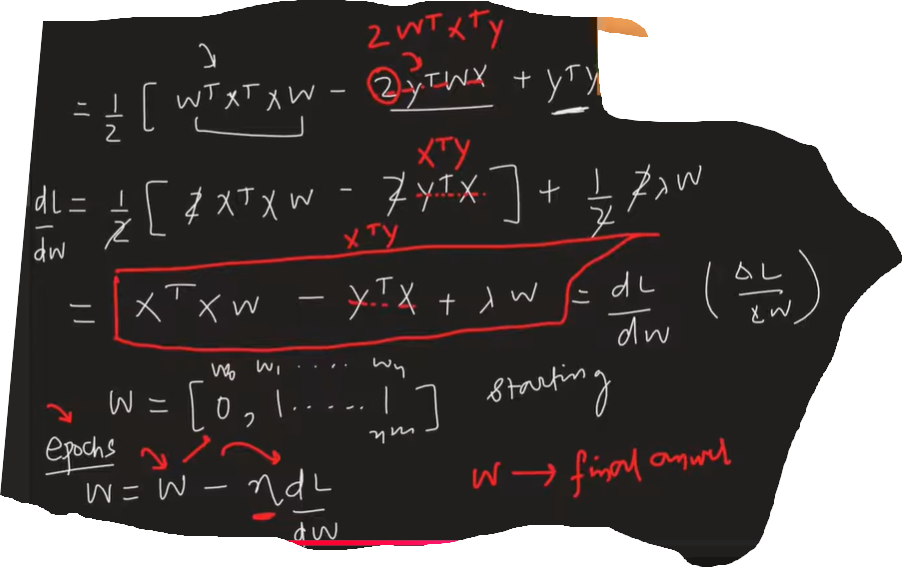

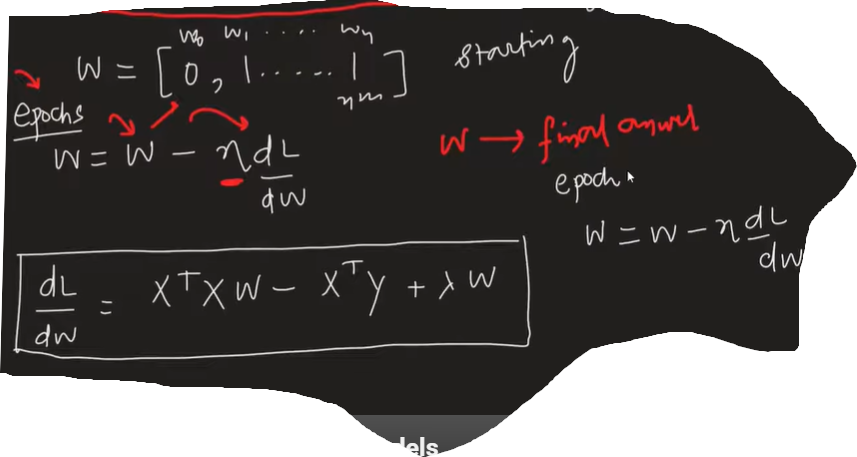

#**Implementation using SGDRegressor**

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np


In [2]:
X,y = load_diabetes(return_X_y=True)

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [9]:
from sklearn.linear_model import SGDRegressor

In [10]:
reg = SGDRegressor(penalty="l2",max_iter=500,eta0=0.1, learning_rate='constant',alpha=0.0001)

In [11]:
reg.fit(X_train,y_train)

SGDRegressor(eta0=0.1, learning_rate='constant', max_iter=500)

In [12]:
y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.47985378830881487
[  46.41332039 -225.9447933   444.71857861  324.12840241  -31.18817636
  -95.94643983 -193.84726444  149.87485358  396.00414623   92.84354032]
[157.81667349]


#**Implementation using Ridge class**

In [13]:
from sklearn.linear_model import Ridge

In [14]:
reg = Ridge(alpha=0.0001,max_iter=500,solver="sparse_cg")

In [15]:
reg.fit(X_train,y_train)

Ridge(alpha=0.0001, max_iter=500, solver='sparse_cg')

In [16]:
y_pred1=reg.predict(X_test)
print("r2 score",r2_score(y_test,y_pred1))
print(reg.coef_)
print(reg.intercept_)

r2 score 0.4612629354571226
[  33.53400572 -292.09005693  481.23388525  368.95064212 -953.55457649
  579.8779238   226.71067256  286.35298975  797.88642647   37.77335539]
151.1416319661695


#**Implementation by making our Own Class**

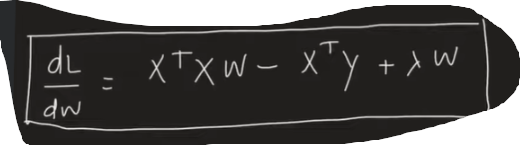

In [21]:
class MyRidgeGD:

  def __init__(self,alpha,epoch,learning_rate):
    self.learning_rate=learning_rate
    self.alpha=alpha
    self.epoch=epoch
    self.coef_=None
    self.intercept_=None

  def fit(self,X_train,y_train):
    self.coef_ = np.ones(X_train.shape[1])
    self.intercept_ = 0
    thetha = np.insert(self.coef_,0,self.intercept_)
    X_train=np.insert(X_train,0,1,axis=1)

    for i in range(self.epoch):
      thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
      thetha = thetha - self.learning_rate*thetha_der

    self.coef_ = thetha[1:]
    self.intercept_ = thetha[0]

  def predict(self,X_test):

    return np.dot(X_test,self.coef_) + self.intercept_



In [22]:
reg = MyRidgeGD(epoch=500,alpha=0.001,learning_rate=0.005)

In [23]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4738018280260913
[  46.65050914 -221.3750037   452.12080647  325.54248128  -29.09464178
  -96.47517735 -190.90017011  146.32900372  400.80267299   95.09048094]
150.86975316713472


******